# **Часть 1.**
## 1. Загрузка и объединение БД

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

red['type'] = 'red'
white['type'] = 'white'

wine = pd.concat([red, white], ignore_index=True)

chem_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

print('Красное вино:', red.shape)
print('Белое вино:', white.shape)
print('Объединенный датасет:', wine.shape)

display(wine.head())

Красное вино: (1599, 13)
Белое вино: (4898, 13)
Объединенный датасет: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 2. Типы столбцов, количество пропущенных значений и число уникальных значений в каждом признаке.

In [ ]:
check = pd.DataFrame({
    'dtype': wine.dtypes.astype(str),
    'missing': wine.isna().sum(),
    'unique_values': wine.nunique()
})

display(check)
print('Всего пропусков:', wine.isna().sum().sum())

,dtype,missing,unique_values
fixed acidity,float64,0,106
volatile acidity,float64,0,187
citric acid,float64,0,89
residual sugar,float64,0,316
chlorides,float64,0,214
free sulfur dioxide,float64,0,135
total sulfur dioxide,float64,0,276
density,float64,0,998
pH,float64,0,108
sulphates,float64,0,111


Всего пропусков: 0


## 3. Полные совпадения строк

В БД нет уникального идентификатора вина, поэтому не факт, что сопавшие строки - ошибочные дубликаты. Чтобы определиться удалять эти строки или нет, можно сравнить структуры данных до и после удаления - распределение `quality`, соотношение red/white, средние и медианные значения признаков и корреляцию признаков с `quality`

In [ ]:
duplicates_table = pd.DataFrame({
    'dataset': ['red', 'white', 'combined'],
    'rows': [len(red), len(white), len(wine)],
    'full_matches': [red.duplicated().sum(), white.duplicated().sum(), wine.duplicated().sum()]
})

duplicates_table['full_matches_%'] = (duplicates_table['full_matches'] / duplicates_table['rows'] * 100).round(2)

display(duplicates_table)

wine_dedup = wine.drop_duplicates().reset_index(drop=True)

print('Исходная выборка:', wine.shape)
print('После удаления полных совпадений:', wine_dedup.shape)
print('Удалено строк:', len(wine) - len(wine_dedup))

,dataset,rows,full_matches,full_matches_%
0,red,1599,240,15.01
1,white,4898,937,19.13
2,combined,6497,1177,18.12


Исходная выборка: (6497, 13)
После удаления полных совпадений: (5320, 13)
Удалено строк: 1177


In [ ]:
quality_compare = pd.DataFrame({
    'raw_count': wine['quality'].value_counts().sort_index(),
    'dedup_count': wine_dedup['quality'].value_counts().sort_index(),
    'raw_%': wine['quality'].value_counts(normalize=True).sort_index() * 100,
    'dedup_%': wine_dedup['quality'].value_counts(normalize=True).sort_index() * 100
})

quality_compare['diff_pp'] = quality_compare['dedup_%'] - quality_compare['raw_%']
quality_compare = quality_compare.round(2)

display(quality_compare)

print('Максимальное изменение доли quality:', quality_compare['diff_pp'].abs().max(), 'п.п.')

,raw_count,dedup_count,raw_%,dedup_%,diff_pp
quality,,,,,
3,30,30,0.46,0.56,0.10
4,216,206,3.32,3.87,0.55
5,2138,1752,32.91,32.93,0.02
6,2836,2323,43.65,43.67,0.01
7,1079,856,16.61,16.09,-0.52
8,193,148,2.97,2.78,-0.19
9,5,5,0.08,0.09,0.02


Максимальное изменение доли quality: 0.55 п.п.


In [ ]:
type_compare = pd.DataFrame({
    'raw_%': wine['type'].value_counts(normalize=True) * 100,
    'dedup_%': wine_dedup['type'].value_counts(normalize=True) * 100
})

type_compare['diff_pp'] = type_compare['dedup_%'] - type_compare['raw_%']
type_compare = type_compare.round(2)

display(type_compare)

print('Максимальное изменение доли type:', type_compare['diff_pp'].abs().max(), 'п.п.')

,raw_%,dedup_%,diff_pp
type,,,
white,75.39,74.45,-0.93
red,24.61,25.55,0.93


Максимальное изменение доли type: 0.93 п.п.


In [ ]:
mean_compare = pd.DataFrame({
    'raw_mean': wine[chem_cols].mean(),
    'dedup_mean': wine_dedup[chem_cols].mean()
})

mean_compare['diff_%'] = (mean_compare['dedup_mean'] - mean_compare['raw_mean']) / mean_compare['raw_mean'] * 100
mean_compare = mean_compare.round(3)

display(mean_compare.sort_values('diff_%', key=lambda x: x.abs(), ascending=False))

print('Максимальное изменение среднего:', mean_compare['diff_%'].abs().max(), '%')

,raw_mean,dedup_mean,diff_%
residual sugar,5.443,5.048,-7.252
free sulfur dioxide,30.525,30.037,-1.601
total sulfur dioxide,115.745,114.109,-1.413
volatile acidity,0.340,0.344,1.314
chlorides,0.056,0.057,1.171
alcohol,10.492,10.549,0.547
sulphates,0.531,0.533,0.393
pH,3.219,3.225,0.191
citric acid,0.319,0.318,-0.044
density,0.995,0.995,-0.016


Максимальное изменение среднего: 7.252 %


In [ ]:
median_compare = pd.DataFrame({
    'raw_median': wine[chem_cols].median(),
    'dedup_median': wine_dedup[chem_cols].median()
})

median_compare['diff'] = median_compare['dedup_median'] - median_compare['raw_median']
median_compare = median_compare.round(3)

display(median_compare.sort_values('diff', key=lambda x: x.abs(), ascending=False))

,raw_median,dedup_median,diff
total sulfur dioxide,118.000,116.000,-2.00
free sulfur dioxide,29.000,28.000,-1.00
residual sugar,3.000,2.700,-0.30
alcohol,10.300,10.400,0.10
volatile acidity,0.290,0.300,0.01
citric acid,0.310,0.310,0.00
fixed acidity,7.000,7.000,0.00
chlorides,0.047,0.047,0.00
density,0.995,0.995,-0.00
pH,3.210,3.210,0.00


In [ ]:
corr_raw = wine[chem_cols + ['quality']].corr()['quality'].drop('quality')
corr_dedup = wine_dedup[chem_cols + ['quality']].corr()['quality'].drop('quality')

corr_compare = pd.DataFrame({
    'raw_corr': corr_raw,
    'dedup_corr': corr_dedup
})

corr_compare['diff'] = corr_compare['dedup_corr'] - corr_compare['raw_corr']
corr_compare = corr_compare.round(3)

display(corr_compare.sort_values('diff', key=lambda x: x.abs(), ascending=False))

print('Максимальное изменение корреляции:', corr_compare['diff'].abs().max())

,raw_corr,dedup_corr,diff
alcohol,0.444,0.469,0.025
density,-0.306,-0.326,-0.021
residual sugar,-0.037,-0.057,-0.020
pH,0.020,0.040,0.020
citric acid,0.086,0.098,0.012
total sulfur dioxide,-0.041,-0.050,-0.009
fixed acidity,-0.077,-0.080,-0.003
sulphates,0.038,0.042,0.003
free sulfur dioxide,0.055,0.054,-0.001
chlorides,-0.201,-0.202,-0.001


Максимальное изменение корреляции: 0.025


После удаления полных совпадений строк структура данных не сильно изменились. Значит можно использовать выборку без полностью совпавших строк

In [ ]:
wine_work = wine_dedup.copy()

print('Размер рабочей выборки:', wine_work.shape)

Размер рабочей выборки: (5320, 13)


## 4. Описательная статистика(среднее, медиана, стандартное отклонение, минимум и максимум)

In [ ]:
stats = wine_work[chem_cols].agg(['mean', 'median', 'std', 'min', 'max']).T.round(3)
display(stats)

,mean,median,std,min,max
fixed acidity,7.215,7.000,1.320,3.800,15.900
volatile acidity,0.344,0.300,0.168,0.080,1.580
citric acid,0.318,0.310,0.147,0.000,1.660
residual sugar,5.048,2.700,4.500,0.600,65.800
chlorides,0.057,0.047,0.037,0.009,0.611
free sulfur dioxide,30.037,28.000,17.805,1.000,289.000
total sulfur dioxide,114.109,116.000,56.774,6.000,440.000
density,0.995,0.995,0.003,0.987,1.039
pH,3.225,3.210,0.160,2.720,4.010
sulphates,0.533,0.510,0.150,0.220,2.000


In [ ]:
ranges = wine_work[chem_cols + ['quality']].agg(['min', 'max']).T
display(ranges)

,min,max
fixed acidity,3.80000,15.90000
volatile acidity,0.08000,1.58000
citric acid,0.00000,1.66000
residual sugar,0.60000,65.80000
chlorides,0.00900,0.61100
free sulfur dioxide,1.00000,289.00000
total sulfur dioxide,6.00000,440.00000
density,0.98711,1.03898
pH,2.72000,4.01000
sulphates,0.22000,2.00000


Явно невозможных значений не обнаружено,отрицательных значений нет

## 5. Проверка выбросов(IQR)

In [ ]:
outliers = []
outlier_mask = pd.Series(False, index=wine_work.index)

for col in chem_cols:
    q1 = wine_work[col].quantile(0.25)
    q3 = wine_work[col].quantile(0.75)
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    cur_mask = (wine_work[col] < low) | (wine_work[col] > high)
    outlier_mask |= cur_mask

    cnt = cur_mask.sum()
    pct = cnt / len(wine_work) * 100

    outliers.append([col, round(low, 3), round(high, 3), cnt, round(pct, 2)])

outliers_df = pd.DataFrame(outliers, columns=['feature', 'low_border', 'high_border', 'outliers_count', 'outliers_%'])

display(outliers_df.sort_values('outliers_%', ascending=False))

print('Строк с хотя бы одним выбросом:', outlier_mask.sum())
print('Доля таких строк:', round(outlier_mask.mean() * 100, 2), '%')

,feature,low_border,high_border,outliers_count,outliers_%
0,fixed acidity,4.450,9.650,304,5.71
1,volatile acidity,-0.040,0.680,279,5.24
4,chlorides,-0.004,0.108,237,4.45
9,sulphates,0.175,0.855,163,3.06
2,citric acid,-0.000,0.640,143,2.69
3,residual sugar,-6.750,16.050,141,2.65
8,pH,2.780,3.660,49,0.92
5,free sulfur dioxide,-21.500,78.500,44,0.83
6,total sulfur dioxide,-44.875,272.125,10,0.19
7,density,0.985,1.004,3,0.06


Строк с хотя бы одним выбросом: 1094
Доля таких строк: 20.56 %


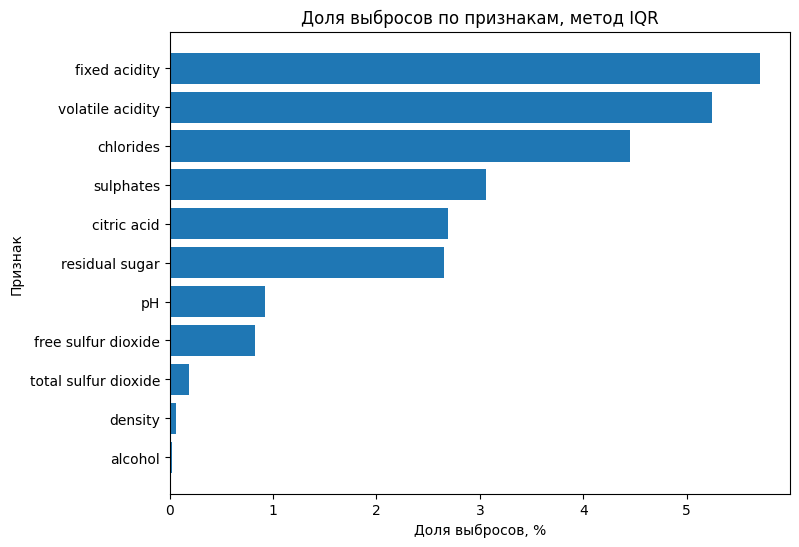

In [ ]:
outlier_plot = outliers_df.sort_values('outliers_%')

plt.figure(figsize=(8, 6))
plt.barh(outlier_plot['feature'], outlier_plot['outliers_%'])

plt.title('Доля выбросов по признакам, метод IQR')
plt.xlabel('Доля выбросов, %')
plt.ylabel('Признак')

plt.show()

Выбросы по IQR есть, но не удалялись - нет явно невозможных значений, а строк с хотя бы одним выбросом слишком много и удалив их, мы теряем большую часть выборки.

## 6. Распределение типа вина и целевой оценки

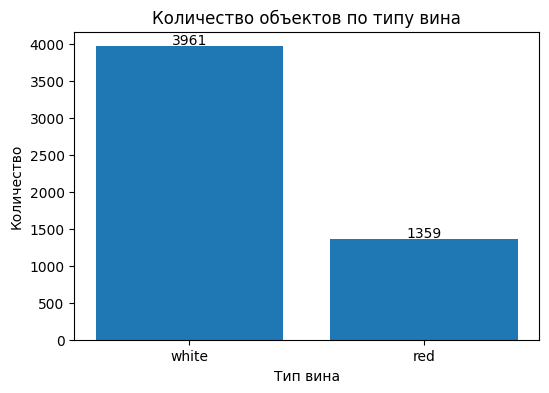

In [ ]:
type_counts = wine_work['type'].value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(type_counts.index, type_counts.values)

plt.title('Количество объектов по типу вина')
plt.xlabel('Тип вина')
plt.ylabel('Количество')
plt.xticks(rotation=0)

for bar, val in zip(bars, type_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, str(val), ha='center')

plt.show()

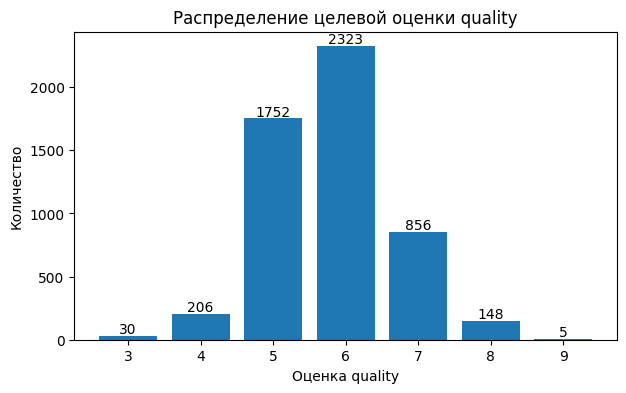

,quality,count,percent
0,3,30,0.56
1,4,206,3.87
2,5,1752,32.93
3,6,2323,43.67
4,7,856,16.09
5,8,148,2.78
6,9,5,0.09


In [ ]:
quality_counts = wine_work['quality'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
bars = plt.bar(quality_counts.index.astype(str), quality_counts.values)

plt.title('Распределение целевой оценки quality')
plt.xlabel('Оценка quality')
plt.ylabel('Количество')
plt.xticks(rotation=0)

for bar, val in zip(bars, quality_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, str(val), ha='center')

plt.show()

quality_dist = pd.DataFrame({
    'quality': quality_counts.index,
    'count': quality_counts.values,
    'percent': (quality_counts.values / len(wine_work) * 100).round(2)
})

display(quality_dist)

Белых вин больше, чем красных. Распределение `quality` неравномерное: оценок 5, 6 больше всего

## **Итог**

Были загружены и объединены два датасета: красные и белые вина. Был добавлен признак `type`.

Пропусков в данных нет. 11 химических признаков имеют числовой тип. Были найдены полные совпадения строк. Так как нет уникального идентификатора вина, нельзя строго доказать, что это ошибочные дубликаты.

Чтобы принять решение на счет удаления полностью совпавших строк сравнили распределение `quality`, соотношение red/white, средние и медианные значения признаков и базовые корреляции с `quality` до и после удаления совпадений. Существенных изменений структуры данных не выявлено, поэтому выбрана версия без полных совпадений строк.

Выбросы по IQR были есть, но автоматически не удалялись, так как в данных нет явно невозможных значений, а редкие химические значения могут соответствовать реальным образцам вина.